# RAG Agent

ReAct Agent에 Retriever를 Tool로 등록하면 **대화형 RAG**가 된다. 기본 RAG 파이프라인은 질문마다 검색을 수행하지만, Agent는 질문을 분석하여 문서 검색이 필요한 경우에만 Retriever Tool을 호출한다.

- 검색 없이 답변할 수 있는 질문은 **Tool 호출 생략**
- 문서 검색이 필요한 질문은 **Retriever Tool 호출**
- Checkpointer를 연결하면 **이전 대화를 기억**하면서 검색

| 구분 | 기본 RAG 파이프라인 | RAG Agent |
|------|----------|-----------|
| 검색 판단 | 항상 검색 | LLM이 필요 여부 판단 |
| 대화 기억 | 별도 구현 필요 | Checkpointer로 유지 |
| 검색 도구 | Retriever를 직접 호출 | Retriever를 Tool로 호출 |


In [6]:
import chromadb
from pathlib import Path

from dotenv import load_dotenv
from google import genai
from google.genai.types import HttpOptions, HttpRetryOptions
from IPython.display import Image, display
from langchain.agents import create_agent
from langchain_chroma import Chroma
from langchain_community.document_loaders import TextLoader
from langchain_core.prompts import PromptTemplate
from langchain_core.tools.retriever import create_retriever_tool
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

EMBEDDING_MODEL_NAME = "gemini-embedding-2"
MODEL_NAME = "gemini-3.6-flash"

# 429 exhausted 해결

retry_client = genai.Client(
    http_options=HttpOptions(
        retry_options=HttpRetryOptions(
            attempts=8,          # 최초 요청 포함 총 8회
            initial_delay=2.0,   # 첫 재시도 대기 시간
            max_delay=60.0,      # 최대 대기 시간
            exp_base=2,          # 지수 백오프 배수 (2초 → 4초 → 8초 → 16초 ...)
            jitter=1.0,          # 대기 시간에 랜덤 지연을 추가해 동시 재시도 요청 분산
        )
    ),
)



### Retriever를 Tool로 변환

먼저 사내 규정 컬렉션에 저장된 청크가 있는지 확인한다. 저장된 청크가 없으면 다음 셀에서 벡터 저장소를 생성하고, 준비된 벡터 저장소를 Retriever Tool로 변환한다.


In [7]:
DATA_DIR = Path("data/company_rules")
PERSIST_DIR = "./chroma_db"
COLLECTION_NAME = "company_rules_search_advanced"

embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)
embeddings.client = retry_client

client = chromadb.PersistentClient(path=PERSIST_DIR)
existing_collections = [collection.name for collection in client.list_collections()]

has_documents = (
    COLLECTION_NAME in existing_collections
    and client.get_collection(COLLECTION_NAME).count() > 0
)

if has_documents:
    collection = client.get_collection(COLLECTION_NAME)
    sample = collection.peek(limit=1)

    print(f"저장된 청크 수: {collection.count()}")
    print(f"metadata: {sample['metadatas'][0]}")
    print(f"content: {sample['documents'][0][:500]}")
else:
    print("저장된 사내 규정이 없습니다. 아래 생성 셀을 실행하세요.")


저장된 청크 수: 77
metadata: {'source': 'IT지원규정.md', 'chunk_id': 'IT지원규정:0'}
content: # IT지원규정

## 제1장 총칙

### 제1조 (목적)
이 규정은 회사의 IT 장비 지급, 소프트웨어 관리, 기술 지원에 관한 사항을 정하는 것을 목적으로 한다. 본 규정은 2024년 4월 1일부터 시행한다.

### 제2조 (적용 범위)
본 규정은 회사의 전 임직원에게 적용된다. 외부 협력사 인원에게는 프로젝트 기간 동안 제한된 범위의 장비를 대여할 수 있으며, 프로젝트 종료 시 즉시 반납해야 한다.

## 제2장 장비 관리

### 제3조 (노트북 지급)
1. 신규 입사자에게는 입사일에 업무용 노트북을 지급한다.
2. 개발직에게는 MacBook Pro 16인치(M4 Pro, 메모리 36GB, SSD 512GB)를 기본 사양으로 지급한다.
3. 비개발직에게는 MacBook Air 15인치(M4, 메모리 24GB, SSD 256GB) 또는 동급 Windows 노트북을 지급한다.
4. 업무 특성상 고사양이 필요한 경우(영상 편집, 3D 렌더링, ML 학습 등), 팀장 승인 후 상


### 벡터 저장소 생성

컬렉션이 없거나 비어 있을 때만 사내 규정 문서를 청크로 나누어 저장한다. 기존 청크가 확인되면 생성 과정을 건너뛴다.


In [11]:
if has_documents:
    print("기존 벡터 저장소를 사용합니다.")
else:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=700,
        chunk_overlap=100,
        separators=["\n### ", "\n\n", "\n", " "],
    )

    documents = []
    for path in sorted(DATA_DIR.glob("*.md")):
        loaded_documents = TextLoader(path, encoding="utf-8").load()
        for document in loaded_documents:
            document.metadata.update({
                "source": path.name,
                "policy_name": path.stem,
            })
        documents.extend(splitter.split_documents(loaded_documents))

    if not documents:
        raise ValueError(f"사내 규정 문서를 찾을 수 없습니다: {DATA_DIR}")

    if COLLECTION_NAME in existing_collections:
        client.delete_collection(COLLECTION_NAME)

    vectorstore = Chroma.from_documents(
        documents=documents,
        embedding=embeddings,
        collection_name=COLLECTION_NAME,
        client=client,
    )
    has_documents = True
    print(f"규정 청크 {len(documents)}개를 새로 저장했습니다.")


규정 청크 77개를 새로 저장했습니다.


### Retriever Tool 생성

`create_retriever_tool`은 Retriever를 Agent가 호출할 수 있는 Tool로 변환하는 함수다. Agent는 Tool의 이름과 설명을 보고 호출 여부를 판단하고, 질문을 `query`로 전달해 관련 문서를 검색한다.

`create_retriever_tool`이 하는 일:
- retriever의 `invoke(query)`를 호출하는 함수를 만든다
- 검색된 Document들의 `page_content`를 합쳐서 문자열로 반환한다
- `name`과 `description`을 Tool 정보로 등록해 LLM이 언제 호출할지 판단하게 한다
- `document_prompt`로 각 검색 문서의 출력 형식을 정한다
- `document_separator`로 여러 검색 문서의 경계를 표시한다

Agent는 Tool의 `description`을 통해 어떤 정보가 들어 있는지와 언제 사용해야 하는지를 판단한다. 따라서 검색 대상과 호출 조건을 구체적으로 작성해야 한다.

Retriever는 `Document` 목록을 반환한다. `create_retriever_tool`은 각 문서의 `page_content`를 문자열로 합쳐 Agent에게 전달하며, 기본 설정에서는 metadata가 포함되지 않는다. 출처처럼 Agent가 답변에 활용해야 하는 metadata는 `document_prompt`에 명시해야 한다.

- `document_prompt`: 검색된 각 `Document`를 어떤 텍스트 형식으로 변환할지 정의한다. `{page_content}`에는 문서 본문이 자동으로 들어가고, `{policy_name}`, `{source}` 같은 나머지 변수에는 같은 이름의 metadata 값이 들어간다.
- `document_separator`: 변환된 여러 문서를 하나의 문자열로 합칠 때 문서 사이에 넣을 구분자다. 여기서는 `---`를 사용해 각 검색 결과의 경계를 표시한다.

`document_prompt`에 사용한 metadata 키는 검색된 모든 문서에 존재해야 한다. 키가 없으면 문서를 변환하는 과정에서 오류가 발생할 수 있다.


In [12]:
if not has_documents:
    raise ValueError("벡터 저장소를 먼저 생성하세요.")

vectorstore = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    client=client,
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

document_prompt = PromptTemplate.from_template(
    "[규정명: {policy_name}]\n"
    "[출처: {source}]\n"
    "{page_content}"
)

retriever_tool = create_retriever_tool(
    retriever,
    name="search_company_rules",
    description=(
        "회사 내부 규정에서 근무 시간, 휴가, 복리후생, 출장비, "
        "보안 및 인사 정책을 검색한다. "
        "회사 규정이나 사내 정책에 관한 질문을 받았을 때 사용한다."
    ),
    document_prompt=document_prompt,
    document_separator="\n\n---\n\n",
)

print(f"Tool 이름: {retriever_tool.name}")
print(f"Tool 설명: {retriever_tool.description}")

Tool 이름: search_company_rules
Tool 설명: 회사 내부 규정에서 근무 시간, 휴가, 복리후생, 출장비, 보안 및 인사 정책을 검색한다. 회사 규정이나 사내 정책에 관한 질문을 받았을 때 사용한다.


### Retriever Tool 직접 호출

Agent가 호출하기 전에 Tool을 직접 실행해 입력 형식과 반환되는 텍스트를 확인한다. 검색된 각 문서에는 `document_prompt`가 적용되고, 문서 사이는 `document_separator`로 구분된다.

In [13]:
query = "연차 휴가는 며칠인가요?"
retrieved_text = retriever_tool.invoke({"query": query})

print(retrieved_text)

# 혹시 여기에서 policy name이 없다는 식으로 에러메시지가 나오면, 위의 vectordb를 새로 생성하세요.

[규정명: 인사규정]
[출처: 인사규정.md]
### 제6조 (초과 근무)
1. 초과 근무는 사전에 팀장의 승인을 받아야 한다.
2. 초과 근무 수당은 통상임금의 1.5배를 지급한다. 야간(22:00~06:00) 및 휴일 초과 근무는 2배를 지급한다.
3. 월 초과 근무 시간은 52시간을 초과할 수 없다. 이는 근로기준법에 따른 강행 규정이다.
4. 초과 근무 대신 대체 휴무를 선택할 수 있으며, 초과 근무 8시간당 1일의 대체 휴무가 부여된다.

## 제4장 휴가

### 제7조 (연차 유급휴가)
1. 1년간 80% 이상 출근한 직원에게 15일의 연차 유급휴가를 부여한다.
2. 3년 이상 근속한 직원에게는 매 2년마다 1일의 가산 휴가를 추가 부여한다.
3. 연차의 최대 한도는 25일로 한다.
4. 연차는 사내 포털 시스템(portal.techstar.co.kr)에서 신청한다.
5. 3일 이상의 연속 휴가는 최소 1주일 전에 신청해야 한다.
6. 미사용 연차는 연말 정산 시 수당으로 지급하며, 통상임금을 기준으로 산정한다.

### 제8조 (특별 휴가)
1. 본인 결혼: 유급 5일
2. 자녀 결혼: 유급 1일
3. 배우자 출산: 유급 10일 (출산일로부터 90일 이내 사용)
4. 부모 또는 배우자 사망: 유급 5일
5. 조부모 또는 형제자매 사망: 유급 3일
6. 특별 휴가는 사유 발생일을 기준으로 사용해야 하며, 분할 사용은 불가하다.

## 제5장 평가 및 보상

---

[규정명: 출장규정]
[출처: 출장규정.md]
### 제7조 (출장 중 주말/공휴일)
1. 출장 기간 중 주말 또는 공휴일이 포함된 경우, 해당 일에 대해서도 숙박비와 일비를 지급한다.
2. 출장 중 주말/공휴일에 업무를 수행한 경우, 대체 휴무를 부여한다.
3. 해외 출장 전후 개인 여행을 연결하는 경우, 개인 여행 기간의 경비는 본인이 부담한다. 항공편은 출장 일정 기준으로 정산한다.

## 제4장 출장 보고

### 제8조 (출장 보고서)
1. 출장자는 복귀 후 3일 이내에 출장 

### RAG Agent 구현

Retriever Tool을 ReAct Agent에 등록한다.

In [14]:
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

graph = create_agent(model=llm, tools=[retriever_tool])

print("RAG Agent 생성 완료")

RAG Agent 생성 완료


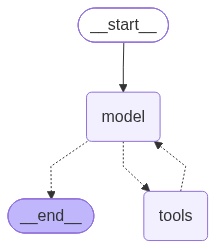

In [15]:
display(Image(graph.get_graph().draw_mermaid_png()))

### 테스트

기존 RAG와의 차이를 확인한다. Agent는 질문에 따라 **검색 여부를 스스로 판단**한다.

In [16]:
# 문서 검색이 필요한 질문
question = "회사 규정상 연차는 며칠이야?"

for event in graph.stream({"messages": [("user", question)]}):
    for node_name, value in event.items():
        last_msg = value["messages"][-1]
        print(f"[{node_name}] {last_msg.type}: {last_msg.text[:200]}")
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tool_call in last_msg.tool_calls:
                print(f"  Tool 이름: {tool_call['name']}")
                print(f"  Tool 인자: {tool_call['args']}")
        print()

[model] ai: 
  Tool 이름: search_company_rules
  Tool 인자: {'query': '연차 휴가 일수 부여 기준'}

[tools] tool: [규정명: 인사규정]
[출처: 인사규정.md]
### 제6조 (초과 근무)
1. 초과 근무는 사전에 팀장의 승인을 받아야 한다.
2. 초과 근무 수당은 통상임금의 1.5배를 지급한다. 야간(22:00~06:00) 및 휴일 초과 근무는 2배를 지급한다.
3. 월 초과 근무 시간은 52시간을 초과할 수 없다. 이는 근로기준법에 따른 강행 규정이다.
4. 초과 

[model] ai: 회사 인사규정(제7조 연차 유급휴가)에 따른 연차 부여 기준은 다음과 같습니다.

1. **기본 연차**: 1년간 80% 이상 출근한 직원에게 **15일**의 연차 유급휴가가 부여됩니다.
2. **가산 휴가**: 3년 이상 근속한 직원에게는 매 2년마다 **1일**의 가산 휴가가 추가 부여됩니다.
3. **최대 한도**: 연차 유급휴가는 최대 **25일**



In [17]:
# 검색 없이 답변 가능한 질문
question = "안녕하세요!"

for event in graph.stream({"messages": [("user", question)]}):
    for node_name, value in event.items():
        last_msg = value["messages"][-1]
        print(f"[{node_name}] {last_msg.type}: {last_msg.text[:200]}")
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tool_call in last_msg.tool_calls:
                print(f"  Tool 이름: {tool_call['name']}")
                print(f"  Tool 인자: {tool_call['args']}")
        print()

[model] ai: 안녕하세요! 무엇을 도와드릴까요? 회사 규정, 근무 시간, 휴가, 복리후생 등 궁금하신 점이 있다면 편하게 물어보세요.



첫 번째 질문에서는 `search_company_rules` Tool을 호출하고, 두 번째 질문에서는 Tool 호출 없이 바로 응답한다. 기존 RAG 파이프라인은 모든 질문에 대해 무조건 검색을 수행하지만, Agent는 **검색이 필요한 경우에만** Tool을 호출한다.

### 문서 기반 답변만 허용하기

RAG Agent는 검색 결과가 없거나 부족해도 LLM의 일반 지식으로 답변할 수 있다. 하지만 사내 문서 QA, 고객 응대 봇처럼 **승인된 문서에 근거한 답변만** 허용해야 하는 경우도 많다. 이때는 System Prompt로 제어한다.

In [18]:
strict_rag_agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt="""
사내 규정과 관련된 질문에는 search_company_rules 도구를 반드시 사용한다.
답변은 검색된 사내 규정만 근거로 작성하고, 참고한 규정명과 출처를 포함한다.
검색 결과에 질문에 답할 충분한 근거가 없으면
'해당 정보를 사내 규정에서 찾을 수 없습니다.'라고 답한다.
사내 규정과 관련 없는 질문에도 같은 문장으로 답하고 도구를 호출하지 않는다.
문서에 없는 내용을 추측하거나 일반 지식으로 보완하지 않는다.
""",
)

print("문서 기반 RAG Agent 생성 완료")

문서 기반 RAG Agent 생성 완료


In [19]:
# 문서에 없는 내용을 질문
result = strict_rag_agent.invoke(
    {"messages": [("user", "오늘 날씨 어때?")]}
)
print("질문: 오늘 날씨 어때?")
print(f"답변: {result['messages'][-1].text}")
print()

# 문서에 있는 내용을 질문
result = strict_rag_agent.invoke(
    {"messages": [("user", "출장 숙박비 한도는 얼마야?")]}
)
print("질문: 출장 숙박비 한도는 얼마야?")
print(f"답변: {result['messages'][-1].text}")

질문: 오늘 날씨 어때?
답변: 해당 정보를 사내 규정에서 찾을 수 없습니다.

질문: 출장 숙박비 한도는 얼마야?
답변: 출장 숙박비 한도는 국내 출장과 해외 출장에 따라 아래와 같습니다.

### **1. 국내 출장 숙박비 한도**
* **서울 및 수도권:** 1박 15만원
* **광역시 (부산, 대구, 대전, 광주):** 1박 12만원
* **기타 지역:** 1박 10만원
※ 당일 출장의 경우 숙박비는 지급되지 않습니다.

### **2. 해외 출장 숙박비 한도**
* **미국/유럽 주요 도시:** 1박 USD 250 이내
* **일본/호주:** 1박 USD 200 이내
* **중국/대만:** 1박 USD 180 이내
* **동남아시아:** 1박 USD 150 이내

---
**[참고 규정 및 출처]**
* **규정명:** 출장규정 (제5조, 제6조) / **출처:** `출장규정.md`
* **규정명:** 경비처리규정 (제7조, 제8조) / **출처:** `경비처리규정.md`


System Prompt 하나로 Agent의 동작이 달라진다:
- 문서에 없는 질문 → 검색 후 관련 내용이 없으면 "찾을 수 없습니다"로 거절
- 문서에 있는 질문 → 검색 결과 기반으로 답변

용도에 따라 선택하면 된다:
- **개방형**: System Prompt 없이 사용. 문서 + 일반 지식으로 폭넓게 답변
- **제한형**: System Prompt로 문서 기반 답변만 허용. 정확성이 중요한 경우

### 대화형 RAG Agent

Checkpointer를 연결하면 이전 대화를 기억하는 RAG 챗봇이 된다. "아까 검색한 내용에서 더 알려줘"같은 후속 질문이 가능해진다.

In [21]:
rag_agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    checkpointer=MemorySaver(),
)

print("대화형 RAG Agent 생성 완료")

대화형 RAG Agent 생성 완료


In [22]:
config = {"configurable": {"thread_id": "rag-session-1"}}

# 첫 번째 질문: 문서 검색
result = rag_agent.invoke(
    {"messages": [("user", "회사 규정상 재택근무는 일주일에 몇 번 가능해?")]},
    config=config,
)
print(result["messages"][-1].text)

회사 규정에 따른 재택근무 가능 횟수는 대상에 따라 다음과 같습니다.

### 1. 일반 기준
* **주 2회까지 가능** (정규직 및 1년 이상 근속한 계약직)
* 전날 18:00까지 사내 포털(`portal.techstar.co.kr`)을 통해 신청해야 하며, 팀 내 최소 출근 인원(50%)을 유지해야 합니다.

### 2. 대상별 세부 기준
* **수습 기간 중인 직원 (입사 후 3개월):** 팀장 승인 시 **주 1회** 가능
* **육아기 직원 (만 8세 이하 자녀):** **주 3회**까지 신청 가능
* **임신 중인 직원:** 출산 예정일 12주 전부터 **전일 재택근무** 신청 가능
* **인턴:** 재택근무 대상에서 제외

---
*참고: 자녀 돌봄이나 건강 사유 등 긴급 상황 발생 시에는 당일 오전 9시까지 사유를 기재하여 신청할 수 있습니다.*


In [23]:
# 두 번째 질문: 이전 대화를 기억한 후속 질문
result = rag_agent.invoke(
    {"messages": [("user", "그 중에서 가장 중요한 것 하나만 골라줘")]},
    config=config,
)
print(result["messages"][-1].text)

회사 규정의 가장 기본이 되는 핵심 사항은 **일반 직원의 재택근무는 ‘주 2회까지 가능’**하다는 점입니다.


In [24]:
# 세 번째 질문: 검색 없이 대화 맥락으로 답변
result = rag_agent.invoke(
    {"messages": [("user", "위 내용을 영어로 번역해줘")]},
    config=config,
)
print(result["messages"][-1].text)

**English Translation:**

"The most fundamental key point under company regulations is that **regular employees are allowed to work from home up to twice a week**."


대화 흐름:
- "재택근무 가능 횟수" → `search_company_rules` Tool 호출 → 규정 기반 답변
- "가장 중요한 것 하나만" → 이전 답변 맥락에서 선별 (Tool 호출 없이 처리)
- "영어로 번역" → Tool 호출 없이 대화 맥락으로 처리

Checkpointer가 없었다면 후속 질문이 가리키는 이전 내용을 파악할 수 없다.


### 실습 문제

SPRi AI Brief 9월호, 10월호, 11월호를 활용하여 AI 산업 동향을 검색하는 대화형 RAG Agent를 구성하라.


In [28]:
import os
import chromadb
from pathlib import Path

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_chroma import Chroma
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()

EMBEDDING_MODEL_NAME = "gemini-embedding-2"
MODEL_NAME = "gemini-3.6-flash"

embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

In [29]:
# 목표 : 대화형 RAG AGENT를 만들고 싶다.
# 필요한 재료, 순서, 어떻게 될지 한글로 적어보자.
# 한글로 적은 후 code로도 작성해보자.(조립 해보자.)

# 1. rag가 필요함.
    # 데이터가 필요함
    # 불러오고, chunking하고, embedding, vectordb에 넣기.   
    # 해당 과정에서 metadata에 신경쓰기.
        # 검색용, 또는 citation용 등등
    # vector store <- 질문을 embedding, 유사도검사 등등을 진행합니다.
    # retriever로 만들면 해결됩니다.
# 2. ReAct, 즉 tools calling할 수 있는 llm, agent가 필요함.
# 3. agent에게 rag를 tool로 쥐어줘야 함.
# 4. rag를 tool로 변경시켜야 함.
    # 어떤 리트리버를 tool로 변경시킬건지.
    # 데이터들을 어떻게 합쳐서 전달할 것인지.
# 5. 대화형을 위해서 checkpoint를 만들어야 함.

In [30]:
# PDF를 일정한 크기의 청크로 나눌 분할기를 준비한다.
DATA_DIR = Path("data")
PERSIST_DIR = "./chroma_db"
COLLECTION_NAME = "spri_search_advanced"
splitter = RecursiveCharacterTextSplitter(
    chunk_size=700, chunk_overlap=100,
)
# 파일명 조건에 맞는 월간 보고서를 찾는다.
pdf_paths = sorted(DATA_DIR.glob("SPRi AI Brief_*월호*.pdf"))
documents = []
# 각 PDF를 불러오고 파일명에서 월 정보를 추출한다.
for path in pdf_paths:
    month_text = path.name.split("_")[1]
    month = int(month_text.removesuffix("월호"))
    pages = PyPDFLoader(path).load()
    # 검색 필터에 사용할 메타데이터를 페이지마다 저장한다.
    for page in pages:
        page.metadata.update({
            "source": path.name, 
            "year": 2025, 
            "month": month,
            "company": "SPRi"
            })
    # 페이지를 청크로 나누고 각 청크에 고유 ID를 부여한다.
    chunks = splitter.split_documents(pages)
    for chunk_index, chunk in enumerate(chunks):
        chunk.metadata["chunk_id"] = f"{path.stem}:{chunk_index}"
    documents.extend(chunks)

# 같은 컬렉션이 있으면 삭제하여 문서가 중복 저장되지 않게 한다.
client = chromadb.PersistentClient(path=PERSIST_DIR)
existing_names = [collection.name for collection in client.list_collections()]
if COLLECTION_NAME in existing_names:
    client.delete_collection(COLLECTION_NAME)

# 모든 청크를 임베딩하여 Chroma에 저장한다.
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    client=client,
)
print(f"PDF {len(pdf_paths)}개, 청크 {len(documents)}개")
print("월호:", [f"{path.name}" for path in pdf_paths])

PDF 3개, 청크 220개
월호: ['SPRi AI Brief_10월호_산업동향_1002_F.pdf', 'SPRi AI Brief_11월호_산업동향_1105_F.pdf', 'SPRi AI Brief_9월호_산업동향_0909_F.pdf']


In [31]:
# vector db => retriever로 만들기
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# retriever => tool로 만들기

# vectorstore에 들어있는 data + meatadata
document_prompt = PromptTemplate.from_template(
    "[출처: {source}]\n"
    "{page_content}"
)

SPRi_retriever_tool = create_retriever_tool(
    retriever,
    name="search_SPRi_ai_Brief",
    description=(
        "SPRi_ai_Brief에 들어있는 ai 산업 관련 동향을 검색한다."
    ),
    document_prompt=document_prompt,
    document_separator="\n\n---\n\n",
)


# 직접 만들어서 metatdata를 llm이 입력할 수 있도록 할수도 있다.
# 아래는 완전한 코드는 아니고, psudo-code 입니다.
# @tool
# def retriever_tool(query, meta):
#     """검색하는 녀석이야. query로 검색하고, metadata로 필터링해.
    
#     Args:
#         query: 검색어
#         meta: key:value 형태의 검색도구. 어떤게 가능한지 여기 적습니다."""
#     context = retriever.invoke('query', filter={**meta})
#     return context

In [34]:
agent = create_agent(
    model = llm,
    tools = [SPRi_retriever_tool],
        system_prompt="""
질문에 대해서 SPRi_retriever_tool 도구를 반드시 사용한다.
답변은 검색된 자료만 근거로 작성하고, 참고한 출처를 포함한다.
검색 결과에 질문에 답할 충분한 근거가 없으면
근거가 없다고 말해.
""",
    checkpointer=MemorySaver(),
)

In [38]:
config = {"configurable": {"thread_id": "rag-session-3"}}

result = agent.stream(
    {"messages": [("user", "즈푸 ai의 동향에 대해서 알려줘.")]},
    config=config,
)

for event in result:
    for node_name, value in event.items():
        last_msg = value["messages"][-1]
        print(f"[{node_name}] {last_msg.type}: {last_msg.text[:200]}")
        if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
            for tool_call in last_msg.tool_calls:
                print(f"  Tool 이름: {tool_call['name']}")
                print(f"  Tool 인자: {tool_call['args']}")
        print()

[model] ai: 
  Tool 이름: search_SPRi_ai_Brief
  Tool 인자: {'query': '즈푸 AI'}

[tools] tool: [출처: SPRi AI Brief_9월호_산업동향_0909_F.pdf]
∙ 두 모델 모두 하이브리드 추론 모델로, 복잡한 추론과 도구 사용을 위한 ‘사고 모드’와 즉각적 응답을 위한 
‘⾮사고 모드’를 제공해 사용자가 필요에 따라 선택할 수 있으며, GLM-4.5는 복잡한 웹페이지나 
인터랙티브 미니 게임 제작과 같은 풀스택 개발 기능을 지원하고 파워포인트

[model] ai: 
  Tool 이름: search_SPRi_ai_Brief
  Tool 인자: {'query': '즈푸'}

[tools] tool: [출처: SPRi AI Brief_9월호_산업동향_0909_F.pdf]
∙ 두 모델 모두 하이브리드 추론 모델로, 복잡한 추론과 도구 사용을 위한 ‘사고 모드’와 즉각적 응답을 위한 
‘⾮사고 모드’를 제공해 사용자가 필요에 따라 선택할 수 있으며, GLM-4.5는 복잡한 웹페이지나 
인터랙티브 미니 게임 제작과 같은 풀스택 개발 기능을 지원하고 파워포인트

[model] ai: 
  Tool 이름: search_SPRi_ai_Brief
  Tool 인자: {'query': 'ZhipuAI GLM'}

[tools] tool: [출처: SPRi AI Brief_9월호_산업동향_0909_F.pdf]
SPRi AI Brief 2025년 9월호
8
즈푸 AI, 추론과 에이전트 성능 강화한 ‘GLM-4.5’ 공개
n 즈푸 AI가 하나의 모델로 추론과 코딩, 에이전트 기능을 모두 수행할 수 있도록 설계된 전문가 
혼합(MOE) 구조의 플래그십 AI 모델 ‘GLM-4.5’와 ‘GLM-4.5

[model] ai: 중국 AI 기업 **즈푸 AI(Zhipu AI)**의 최근 주요 동향은 다음과 같습니다.

---

### 1. 차세대 플래그십 AI 모델 ‘GLM-4.5’ 공개 및 오픈소스화
* **오픈소스 공